In [3]:
import sys
sys.path.append('../src/')
import dust2dusty
import numpy as np


In [4]:
import argparse
import yaml
args = argparse.Namespace(
    CONFIG_FILE='../config/config_popovic2023.yml',
    OUTPUT_DIR='./TEST_OUTPUT',
    TEST_RUN=False,
    DEBUG_RUN=False,
    DEBUG_FULL=False,
    NOWEIGHT=False,
    VERBOSE=False,
    FORCE_OVERRIDE=True,
    SAMPLER="emcee"
)
DEFAULT_PARAMETER_RANGES = {
        "c": np.arange(-0.5, 0.5, 0.001),
        "x1": np.arange(-5, 5, 0.01),
        "RV": np.arange(0, 8, 0.1),
        "EBV": np.arange(0.0, 1.5, 0.02),
        "EBVZ": np.arange(0.0, 1.5, 0.02),
    }
fake_yaml = """
SALT2MU_GENDPDF_GRID:
    HOST_LOGMASS:
        method: arange
        args: [5, 15, 1]
    SIM_ZCMB:
        method: linspace
        args: [-2.4, 2.6, 3]
"""
fake_dic_genpdf_grid = yaml.safe_load(fake_yaml)["SALT2MU_GENDPDF_GRID"]

In [5]:
import logging
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s [%(levelname)s] %(message)s",
    stream=sys.stdout,   # notebooks buffer stderr; stdout shows immediately
    force=True,          # re-configures if logging was already set up
)
log = logging.getLogger(__name__)

In [35]:
import importlib

importlib.reload(dust2dusty.utils)
importlib.reload(dust2dusty.salt2mu)

importlib.reload(dust2dusty.cli)
importlib.reload(dust2dusty)


<module 'dust2dusty' from '/hpc/group/cosmology/blc56/Soft/dust2dusty/debug_notebooks/../src/dust2dusty/__init__.py'>

In [7]:
cfg = dust2dusty.cli._load_config(args, log)

2026-03-17 11:46:07,935 [INFO] Loaded configuration from: ../config/config_popovic2023.yml
2026-03-17 11:46:07,935 [WARNING] Removing existing output directory: /hpc/group/cosmology/blc56/Soft/dust2dusty/debug_notebooks/TEST_OUTPUT
2026-03-17 11:46:07,949 [DEBUG] Create main directory /hpc/group/cosmology/blc56/Soft/dust2dusty/debug_notebooks/TEST_OUTPUT
2026-03-17 11:46:07,958 [DEBUG] Create sub directory /hpc/group/cosmology/blc56/Soft/dust2dusty/debug_notebooks/TEST_OUTPUT/chains
2026-03-17 11:46:07,959 [DEBUG] Create sub directory /hpc/group/cosmology/blc56/Soft/dust2dusty/debug_notebooks/TEST_OUTPUT/logs
2026-03-17 11:46:07,961 [DEBUG] Create sub directory /hpc/group/cosmology/blc56/Soft/dust2dusty/debug_notebooks/TEST_OUTPUT/realdata_salt2mu_files
2026-03-17 11:46:07,962 [DEBUG] Create sub directory /hpc/group/cosmology/blc56/Soft/dust2dusty/debug_notebooks/TEST_OUTPUT/worker_salt2mu_files
2026-03-17 11:46:07,963 [INFO] Configuration finalized successfully:
2026-03-17 11:46:07,96

In [8]:
from itertools import product, chain

In [9]:
sampled_par_names, p0_init, p0_std, p0_bounds, log_sampling = dust2dusty.utils.get_sampled_par_names_and_init(cfg) 

theta_dic = dict(zip(sampled_par_names, p0_init))

In [11]:
param_dic["splits"]

{'SIM_ZCMB': 0.1, 'HOST_LOGMASS': 10}

In [163]:
%%time
param_name, param_dic = list(cfg.fitted_params.items())[0]

param_dist_vals_dic = {k: v for k, v in theta_dic.items() if param_name in k}



split_pars = []
if "splits" in param_dic:
    split_pars = list(param_dic["splits"].keys())

genpdf_grid_param_range = {**fake_dic_genpdf_grid, **DEFAULT_PARAMETER_RANGES}
for key, val in genpdf_grid_param_range.items():
    if isinstance(val, dict):
        genpdf_grid_param_range[key] = getattr(np, val["method"])(*val["args"])

genpdf_par_grid, *genpdf_split_grid = np.meshgrid(
    genpdf_grid_param_range[param_name],
    *[genpdf_grid_param_range[split_p] for split_p in split_pars],
)
genpdf_split_grid_dic = {split_p: genpdf_split_g for split_p, genpdf_split_g in zip(split_pars, genpdf_split_grid)}
genpdf_probs_grid = np.zeros_like(genpdf_par_grid)


CPU times: user 133 μs, sys: 0 ns, total: 133 μs
Wall time: 127 μs


In [164]:
import operator
_OPERATOR_MAP = {"low": operator.lt, "high": operator.gt}


{}

In [165]:

#split_pars = list(param_dic["splits"].keys())
split_pars = []
param_dist_vals_subdic = {}

comb_list = list(product(*[[f"{split_p}_{l}" for l in ["low", "high"]] for split_p in split_pars]))
for comb in comb_list:
    key = "_" + "_".join(comb)
    
    if key == "_":
        key = ""
    
    param_dist_vals_subdic = {
                    k.replace(f"{key}", ""): v
                    for k, v in param_dist_vals_dic.items()
                    if key in k
                   }
    
    
    
    mask = np.ones_like(genpdf_probs_grid, dtype=bool)
    for split_p in split_pars:
        if f"{split_p}_low" in key:
            mask &= _OPERATOR_MAP["low"](genpdf_split_grid_dic[f"{split_p}"], param_dic["splits"][f"{split_p}"])
        elif f"{split_p}_high" in key:
            mask &= _OPERATOR_MAP["high"](genpdf_split_grid_dic[f"{split_p}"], param_dic["splits"][f"{split_p}"])
        else:
            raise ValueError()
    
    #genpdf_probs_grid[mask] = dust2dusty.SALT2mu.get_1d_exponential(param_dist_vals_subdic[param_name + "_tau"], genpdf_par_grid[mask])
    genpdf_probs_grid[mask] = dust2dusty.SALT2mu.get_1d_asym_gauss(
                param_dist_vals_subdic[param_name + "_mu"],
                param_dist_vals_subdic[param_name + "_std"],
                param_dist_vals_subdic[param_name + "_std"],
                genpdf_par_grid[mask],
            )

2026-03-17 12:25:56,527 [DEBUG] CACHEDIR=/hpc/home/blc56/.cache/matplotlib
2026-03-17 12:25:56,548 [DEBUG] Using fontManager instance from /hpc/home/blc56/.cache/matplotlib/fontlist-v390.json
2026-03-17 12:25:58,391 [DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-17 12:25:58,391 [DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-17 12:25:58,393 [DEBUG] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-03-17 12:25:58,393 [DEBUG] findfont: score(FontEntry(fname='/hpc/group/cosmology/blc56/miniconda3/envs/DEBASS/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-03-17 12:25:58,394 [DEBUG] findfont: score(FontEntry(fname='/hpc/group/cosmology/blc56/miniconda3/envs/DEBASS/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf

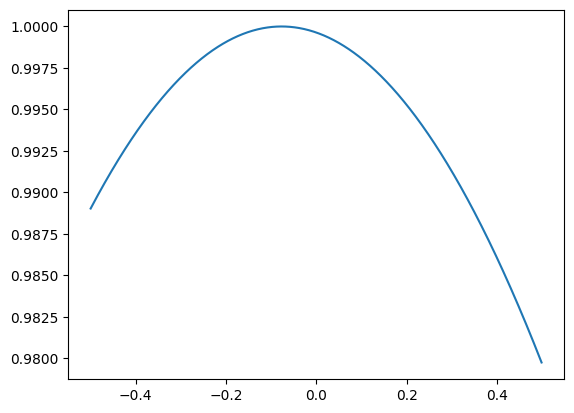

In [171]:
import matplotlib.pyplot as plt

plt.plot(genpdf_par_grid.flatten(), genpdf_probs_grid.flatten())

In [169]:
print(write_probs(genpdf_par_grid, genpdf_split_grid, genpdf_probs_grid))

PDF: -0.500     0.989
PDF: -0.499     0.989
PDF: -0.498     0.989
PDF: -0.497     0.989
PDF: -0.496     0.989
PDF: -0.495     0.989
PDF: -0.494     0.989
PDF: -0.493     0.989
PDF: -0.492     0.989
PDF: -0.491     0.989
PDF: -0.490     0.990
PDF: -0.489     0.990
PDF: -0.488     0.990
PDF: -0.487     0.990
PDF: -0.486     0.990
PDF: -0.485     0.990
PDF: -0.484     0.990
PDF: -0.483     0.990
PDF: -0.482     0.990
PDF: -0.481     0.990
PDF: -0.480     0.990
PDF: -0.479     0.990
PDF: -0.478     0.990
PDF: -0.477     0.990
PDF: -0.476     0.990
PDF: -0.475     0.990
PDF: -0.474     0.990
PDF: -0.473     0.990
PDF: -0.472     0.990
PDF: -0.471     0.990
PDF: -0.470     0.991
PDF: -0.469     0.991
PDF: -0.468     0.991
PDF: -0.467     0.991
PDF: -0.466     0.991
PDF: -0.465     0.991
PDF: -0.464     0.991
PDF: -0.463     0.991
PDF: -0.462     0.991
PDF: -0.461     0.991
PDF: -0.460     0.991
PDF: -0.459     0.991
PDF: -0.458     0.991
PDF: -0.457     0.991
PDF: -0.456     0.991
PDF: -0.45

In [91]:
def write_probs(
    genpdf_var, split_vars, genpdf_probs
) -> None:
    """
    Write 2D probability distribution to crosstalk file.

    Args:
        arr: Array of primary variable values.
        mass: Mass value (scalar).
        probs: Array of probability values (same length as arr).

    Side Effects:
        Writes "PDF: value mass prob" lines to crosstalk file.
    """
    format_sring = "PDF: {:.3f}" + "{:8.2f}" * len(split_vars) + "  {:8.3f}\n"
    bigstr = ""
    
    for a, *sp, p in zip(genpdf_var.flatten(), *[sp.flatten() for sp in split_vars], genpdf_probs.flatten()):
        bigstr += format_sring.format(a, *sp, p)
    return bigstr

In [81]:
format_sring = "PDF: {:.3f}" + "{:5.2f}" * len(genpdf_split_grid) + " {:.3f}\n"


In [67]:
format_sring.format()

'PDF: {:.3f} {:.2f} {:.2f} {:.3f}\n'

In [33]:
dust2dusty.SALT2mu.get_1d_exponential(param_dist_vals_subdic[param_name + "_tau"], genpdf_par_grid[mask])

(array([0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.02, 0.02, 0.02, 0.02, 0.04,
        0.04, 0.04, 0.04, 0.04, 0.06, 0.06, 0.06, 0.06, 0.06, 0.08, 0.08,
        0.08, 0.08, 0.08, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.12, 0.12, 0.12,
        0.12, 0.12, 0.14, 0.14, 0.14, 0.14, 0.14, 0.16, 0.16, 0.16, 0.16,
        0.16, 0.18, 0.18, 0.18, 0.18, 0.18, 0.2 , 0.2 , 0.2 , 0.2 , 0.2 ,
        0.22, 0.22, 0.22, 0.22, 0.22, 0.24, 0.24, 0.24, 0.24, 0.24, 0.26,
        0.26, 0.26, 0.26, 0.26, 0.28, 0.28, 0.28, 0.28, 0.28, 0.3 , 0.3 ,
        0.3 , 0.3 , 0.3 , 0.32, 0.32, 0.32, 0.32, 0.32, 0.34, 0.34, 0.34,
        0.34, 0.34, 0.36, 0.36, 0.36, 0.36, 0.36, 0.38, 0.38, 0.38, 0.38,
        0.38, 0.4 , 0.4 , 0.4 , 0.4 , 0.4 , 0.42, 0.42, 0.42, 0.42, 0.42,
        0.44, 0.44, 0.44, 0.44, 0.44, 0.46, 0.46, 0.46, 0.46, 0.46, 0.48,
        0.48, 0.48, 0.48, 0.48, 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.52, 0.52,
        0.52, 0.52, 0.52, 0.54, 0.54, 0.54, 0.54, 0.54, 0.56, 0.56, 0.56,
        0.56, 0.56, 0.58, 0.58, 0.58, 

In [26]:
genpdf_probs_grid.shape

(3, 75, 10)

In [ ]:
dist_par_dic

In [ ]:
param_dic["splits"][]

In [ ]:
param_dist_vals_subdic

In [ ]:
RV_GRID = dust2dusty.SALT2mu.DEFAULT_PARAMETER_RANGES['RV']

HOST_LOGMASS_GRID = np.arange(5,15,1)

RV, HLM = np.meshgrid(RV_GRID,HOST_LOGMASS_GRID)

In [ ]:
P = np.zeros_like(RV)

In [ ]:
P[HLM < 10] = RV[HLM < 10]

In [ ]:
P.flatten()

In [ ]:
%%time
theta_dic = dict(zip(sampled_par_names, p0_init))

In [ ]:
param_name = 'RV'
param_dist_vals_dic = {k: v for k, v in theta_dic.items() if param_name in k}
split_pars = list(cfg.fitted_params['RV']["splits"].keys())


In [ ]:
param_vals = {}
for l in ["low", "high"]:
    param_vals[l] = {
        k.replace(f"_{split_pars[0]}_{l}", ""): v
        for k, v in param_dist_vals_dic.items()
        if f"_{split_pars[0]}_{l}" in k
    }


In [ ]:
param_vals

In [ ]:
%%timeit
pattern = '_HOST_LOGMASS_high'
{k.replace(pattern, ""): v for k, v in param_dist_vals_dic.items() if pattern in k}

In [ ]:
theta_dic = dict(zip(["par_names"], theta))


In [ ]:
theta_dic

In [ ]:
param_dist_values = p0_init[np.char.startswith(sampled_par_names, 'RV')]

temp = []
n_shape_params = len(cfg.DISTRIBUTION_PARAMETERS[cfg.fitted_params['RV']['dist']])
for i in range(len(cfg.fitted_params['RV']['splits'].keys()) * 2):
    temp.append(param_dist_values[i * n_shape_params : (i + 1) * n_shape_params])
temp

In [ ]:
getattr(np, 'arange')

In [ ]:
np.arange(*[5, 15,1])

In [ ]:
from itertools import combinations
def get_sampled_par_names_and_init(config) -> list[str]:
    sampled_par_names = []
    for p, pdic in config.fitted_params.items():
        if "splits" not in pdic:
            sampled_par_names.extend(
                [f"{p}_{dist_p}" for dist_p in config.DISTRIBUTION_PARAMETERS[pdic["dist"]]]
            )
        else:
            splits = pdic["splits"].keys()
            split_string = f"{p}_{{}}_" + "_".join([f"{split_p}_{{}}" for split_p in splits])
            split_states = []
            for r in range(len(splits) + 1):
                for low_vars in combinations(splits, r):
                    split_states.append(["low" if v in low_vars else "high" for v in splits])

            sampled_par_names.extend(
                [
                    split_string.format(dist_p, *split_st)
                    for split_st in split_states
                    for dist_p in config.DISTRIBUTION_PARAMETERS[pdic["dist"]]
                ]
            )
    p0_mu = np.array([config.parameter_inits[p]["p0"] for p in sampled_par_names])
    p0_std = np.array([config.parameter_inits[p]["p0_std"] for p in sampled_par_names])
    log_sampling = np.array(
        [True if "tau" in p or "std" in p else False for p in sampled_par_names], dtype=bool
    )

    # log sampling of variance
    p0_mu[log_sampling] = np.log(p0_mu[log_sampling])
    p0_std[log_sampling] = np.log(p0_std[log_sampling])

    par_bounds = np.array(
        [
            config.parameter_inits[p]["bounds"]
            if not log_sampling[i]
            else [-np.inf, np.log(config.parameter_inits[p]["bounds"][-1])]
            for i, p in enumerate(sampled_par_names)
        ]
    )

    return sampled_par_names, p0_mu, p0_std, par_bounds, log_sampling


In [ ]:
pconv(cfg.fitted_params, cfg.param_dists, cfg.param_splits, cfg.DISTRIBUTION_PARAMETERS)

In [ ]:
splits_on = cfg.param_splits['EBV'].keys()


In [ ]:
p = "RV"
cfg.DISTRIBUTION_PARAMETERS[cfg.param_dists[p]]

In [ ]:
def pconv(
    inp_params: list[str],
    paramshapesdict: dict[str, str],
    splitdict: dict[str, dict[str, float]],
    distribution_parameters: dict[str, list[str]],
) -> list[str]:
    """
    Convert input parameters to expanded parameter list.

    Takes high-level parameter names and expands them into a full list of
    distribution parameters, accounting for:
    1. Distribution shape (Gaussian needs mu+std, Exponential needs tau, etc.)
    2. Parameter splits (e.g., different values for low/high mass)

    Example:
        >>> pconv(['RV'], {'RV': 'Gaussian'}, {'RV': {'HOST_LOGMASS': 10}},
        ...       {'Gaussian': ['mu', 'std']})
        ['RV_HOST_LOGMASS_low_mu', 'RV_HOST_LOGMASS_low_std',
         'RV_HOST_LOGMASS_high_mu', 'RV_HOST_LOGMASS_high_std']

    Args:
        inp_params: List of high-level parameter names (e.g., ['c', 'RV', 'EBV']).
        paramshapesdict: Maps parameter to distribution shape
            (e.g., {'c': 'Gaussian'}).
        splitdict: Nested dict defining parameter splits.
            Format: {param: {split_var: split_value}}.
            Example: {'RV': {'HOST_LOGMASS': 10, 'SIM_ZCMB': 0.1}}.
        distribution_parameters: Dict mapping distribution names to their
            parameter names (e.g., {'Gaussian': ['mu', 'std']}).

    Returns:
        Expanded parameter names (length = ndim for MCMC).
        Format: 'PARAM_SPLITVAR1_lowhigh_SPLITVAR2_lowhigh_..._DISTPARAM'.
    """
    inpfull: list[list[str]] = []
    for i in inp_params:
        initial_dimension = list(distribution_parameters[paramshapesdict[i]])
        if i in splitdict.keys():
            things_to_split_on = splitdict[i]
            nsplits = len(things_to_split_on)
            params_to_split_on = things_to_split_on.keys()
            # Create format string like "{}_{}_{}_{}" for nsplits*2 parameters
            format_string = "_".join(["{}"] * nsplits * 2)
            lowhigh_array = np.tile(["low", "high"], [nsplits, 1])
            splitlist = []
            for lowhigh_combo in itertools.product(*lowhigh_array):
                to_format = [val for pair in zip(params_to_split_on, lowhigh_combo) for val in pair]
                final = format_string.format(*to_format)
                splitlist.append(final)
            initial_dimension = [
                tmp[1] + "_" + tmp[0] for tmp in itertools.product(splitlist, initial_dimension)
            ]
        final_dimension = [i + "_" + s for s in initial_dimension]
        inpfull.append(final_dimension)
    return [item for sublist in inpfull for item in sublist]
